**Assignment-3**
Developed an end-to-end Customer Intelligence System using classification, ensemble learning (Random Forest, XGBoost), and clustering (K-Means, DBSCAN), achieving optimized predictive performance and actionable customer segmentation insights.

As the data is about the Different Countries , so applying Clustering and Segregating countries into 3 parts

A]Developed
B]Developing
C]Underdeveloped

In [102]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [103]:
df = pd.read_csv("downloads/Customer/country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


**EDA**

In [104]:
df.shape


(167, 10)

This shows that their are in total 10 columns and 167 rows

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


This shows that none of the feild is null and also displays the Dtype

In [106]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


describe helped us to find the basic numerical interpretations, like mean,avg, min etc from each feild

In [107]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Hence non of the field or any entry has Nan or null column 

Let's find Correlation:
we will only take numerical data ,hence not using the **country column**

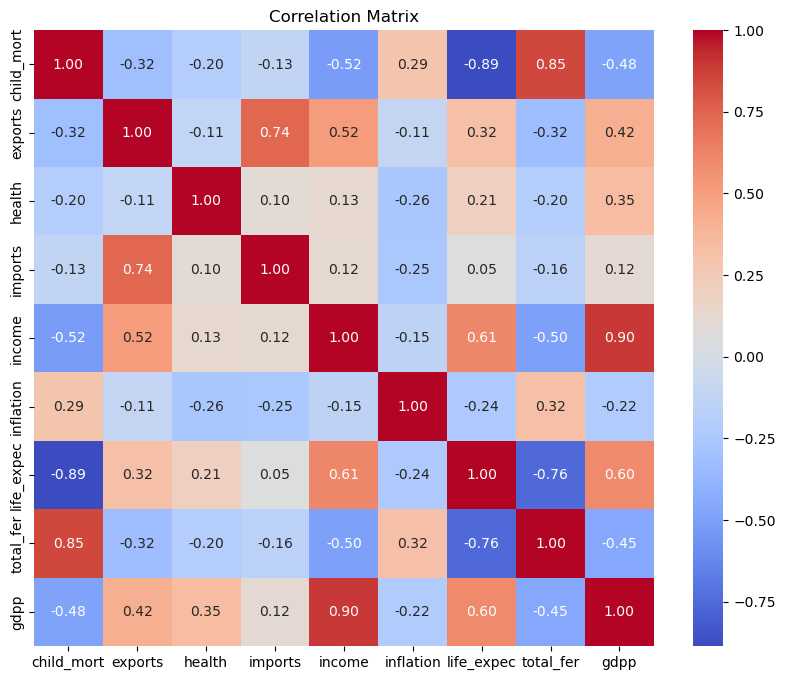

In [108]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [109]:
col = list(df.columns)
col.remove('country')
categorical_features = ['country']
numerical_features = [*col]
print('Categorical Features :',*categorical_features)
print('Numerical Features :',*numerical_features)

Categorical Features : country
Numerical Features : child_mort exports health imports income inflation life_expec total_fer gdpp


Creating a potential score where we will only include income,gdp and life_expec of a country beacause these factors could actually help us understand which country could be a good customer.

In [110]:
df["PotentialScore"] = (

      0.40 * df["income"]
    + 0.40 * df["gdpp"]
    + 0.20 * df["life_expec"]

)

In [111]:
median_score = df["PotentialScore"].median()

df["Target"] = np.where(
    df["PotentialScore"] > median_score,
    1,
    0
)

In [112]:
df["PotentialScore"].describe()

count      167.000000
mean     12057.648862
std      14646.086657
min        388.700000
25%       2100.910000
50%       6007.580000
75%      14555.050000
max      78696.260000
Name: PotentialScore, dtype: float64

Dropping Country column

In [113]:
model_df = df.drop("country", axis=1)

Feature Scaling: also checking it by comparing both describe(before feature scaling and after feature scaling), then checking the shape of before and after, to confirm that their is no error while training

In [114]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    model_df.drop("Target", axis=1)
)

In [115]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=model_df.drop("Target", axis=1).columns
)

print(scaled_df.mean())

print(scaled_df.std())

child_mort       -3.722904e-17
exports           2.127373e-16
health            5.504579e-16
imports           2.765585e-16
income           -7.977650e-17
inflation        -1.063687e-17
life_expec        3.696311e-16
total_fer         3.044803e-16
gdpp              5.850277e-17
PotentialScore   -2.526256e-17
dtype: float64
child_mort        1.003008
exports           1.003008
health            1.003008
imports           1.003008
income            1.003008
inflation         1.003008
life_expec        1.003008
total_fer         1.003008
gdpp              1.003008
PotentialScore    1.003008
dtype: float64


In [116]:
print(model_df.describe())

print(scaled_df.describe())

       child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167.000000   
mean    38.270060   41.108976    6.815689   46.890215   17144.688623   
std     40.328931   27.412010    2.746837   24.209589   19278.067698   
min      2.600000    0.109000    1.810000    0.065900     609.000000   
25%      8.250000   23.800000    4.920000   30.200000    3355.000000   
50%     19.300000   35.000000    6.320000   43.300000    9960.000000   
75%     62.100000   51.350000    8.600000   58.750000   22800.000000   
max    208.000000  200.000000   17.900000  174.000000  125000.000000   

        inflation  life_expec   total_fer           gdpp  PotentialScore  \
count  167.000000  167.000000  167.000000     167.000000      167.000000   
mean     7.781832   70.555689    2.947964   12964.155689    12057.648862   
std     10.570704    8.893172    1.513848   18328.704809    14646.086657   
min     -4.210000   32.100000    1.150000     2

In [117]:
print(model_df.drop("Target", axis=1).shape)
print(scaled_data.shape)

(167, 10)
(167, 10)


Elbow method: used for clustering basically helps to find the number of clusters

The Elbow Method plots the number of clusters against WCSS (Within Cluster Sum of Squares). As the number of clusters increases, WCSS decreases because data points become closer to their cluster centroids. The optimal number of clusters is chosen at the elbow point where adding more clusters produces only marginal improvements in WCSS.

In [118]:
wcss = []

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42
    )

    km.fit(scaled_data)

    wcss.append(km.inertia_)

Here WCSS= within clusters sum of squares

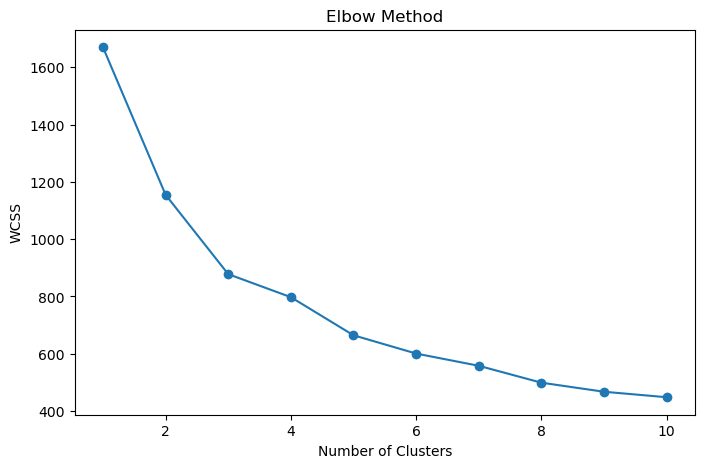

In [119]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

K-Mean Clustering(K=3)

In [120]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(
    scaled_data
)

Cluster Distribution

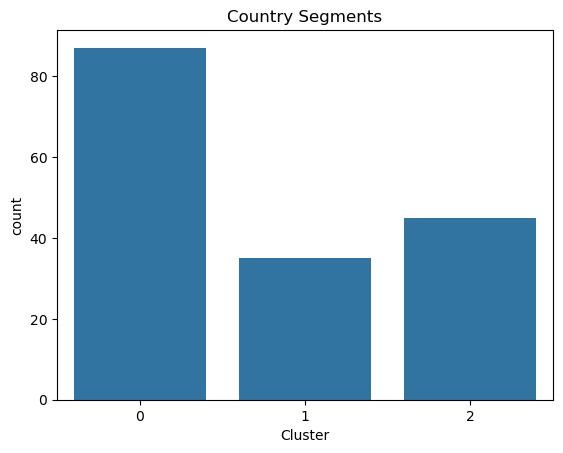

In [121]:
sns.countplot(
    x=df["Cluster"]
)

plt.title("Country Segments")
plt.show()

In [123]:
df[df['gdpp'] == 'Cluster 0']['country']

Series([], Name: country, dtype: object)

Cluster Visualization/ Visual testing of formation of clusters

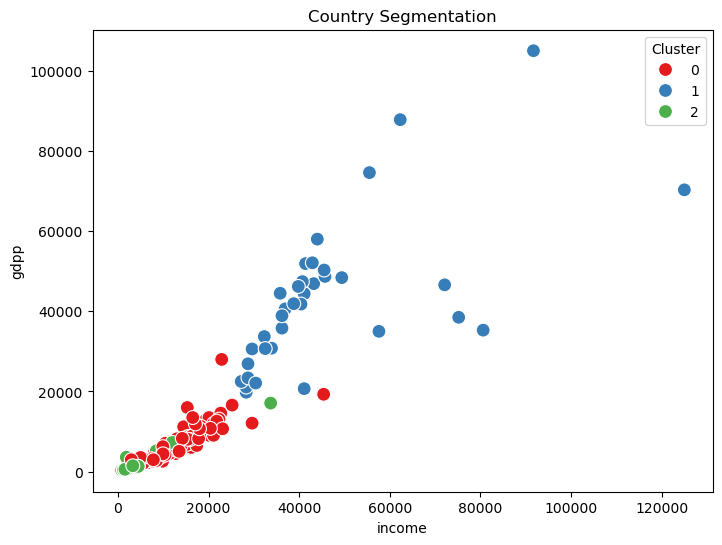

In [124]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=df,

    x="income",
    y="gdpp",

    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("Country Segmentation")
plt.show()

DBSCAN:
Unlike \(K\)-Means, which forces every point into a spherical group, DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is used to find clusters based on how tightly packed data points are.It is specifically chosen when your data has irregular shapes, contains heavy background noise, or when you do not know how many clusters exist.

In [125]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

df["DBSCAN_Cluster"] = dbscan.fit_predict(
    scaled_data
)

In [126]:
df["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
 0    134
-1     33
Name: count, dtype: int64

here DBSCAN hase distributed data to only cluster0 having 134 values, and -1 represents those outliers which are considerd noise by DBSCAN

Testing:

In [158]:
df["Cluster"].value_counts()

Cluster
0    87
2    45
1    35
Name: count, dtype: int64

In [159]:
df.groupby("Cluster")[[
    "income",
    "gdpp",
    "life_expec",
    "child_mort"
]].mean()

,income,gdpp,life_expec,child_mort
Cluster,,,,
0,12469.770115,6578.298851,72.600000,22.279310
1,46257.142857,43234.285714,80.260000,4.942857
2,3539.844444,1766.711111,59.055556,95.106667


For above table
we get the interpretations as

cluster 0- Developed
cluster 1- Developing
cluster 2- Underdeveloped

Silhouette Score(Best Testing metric)

In [160]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    scaled_data,
    df["Cluster"]
)

print(score)

0.3023868247438503


this value shows that the clusters are well seperated

Testing using specific coutries

In [166]:
df[["country","Cluster"]].head(80)

,country,Cluster
0,Afghanistan,2
1,Albania,0
2,Algeria,0
3,Angola,2
4,Antigua and Barbuda,0
...,...,...
75,Italy,1
76,Jamaica,0
77,Japan,1
78,Jordan,0


CLASSIFICATION:

In [127]:
df.head(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,PotentialScore,Target,Cluster,DBSCAN_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,876.44,0,2,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,5623.26,0,0,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,6959.30,1,0,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,3784.02,0,2,-1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,12535.36,1,0,0


In [128]:
X = model_df.drop(
    ["Target"],
    axis=1
)

y = model_df["Target"]

In [129]:
df.head(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,PotentialScore,Target,Cluster,DBSCAN_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,876.44,0,2,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,5623.26,0,0,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,6959.30,1,0,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,3784.02,0,2,-1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,12535.36,1,0,0


Splitting of training and testing datasets

In [130]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,
    random_state=42,
    stratify=y
)

In [131]:
X_train.shape

(133, 10)

In [132]:
X_test.shape

(34, 10)

In [133]:
y_train.shape

(133,)

In [134]:
y_test.shape

(34,)

Applying RandomForest:

In [135]:
rf = RandomForestClassifier(

    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(X_test)

In [136]:
print(
    "Accuracy:",
    accuracy_score(y_test,pred_rf)
)

Accuracy: 1.0


In [137]:
print(
    classification_report(
        y_test,
        pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



Confusion Matrix:

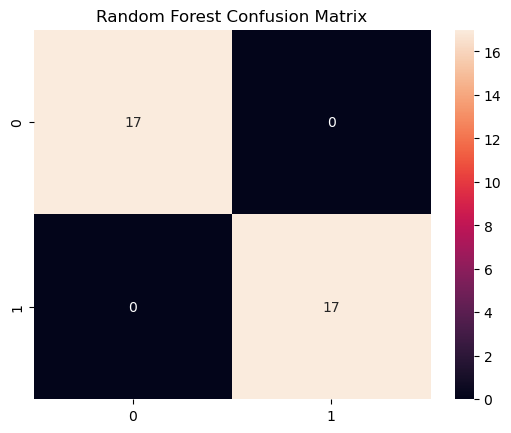

In [138]:
cm = confusion_matrix(
    y_test,
    pred_rf
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Random Forest Confusion Matrix")
plt.show()

Applying XGBoost

In [139]:
xgb = XGBClassifier(

    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,

    random_state=42
)

In [140]:
xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [141]:
pred_xgb = xgb.predict(X_test)

In [142]:
print(
    "Accuracy:",
    accuracy_score(y_test,pred_xgb)
)

Accuracy: 1.0


Comparison of both types of classifiers used

RandomForest and XGBoost

In [143]:
results = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[

        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_xgb)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Random Forest,1.0
1,XGBoost,1.0


Here the accuracy by using both classifiers is 100 only

**Feature Importance**

In [144]:
importance = pd.DataFrame({

    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

In [145]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
9,PotentialScore,0.323079
4,income,0.282786
8,gdpp,0.221006
0,child_mort,0.085873
6,life_expec,0.052574
7,total_fer,0.024776
1,exports,0.004236
5,inflation,0.003685
3,imports,0.001125
2,health,0.000861


The above list is of which features are important, and the list in decreasing order

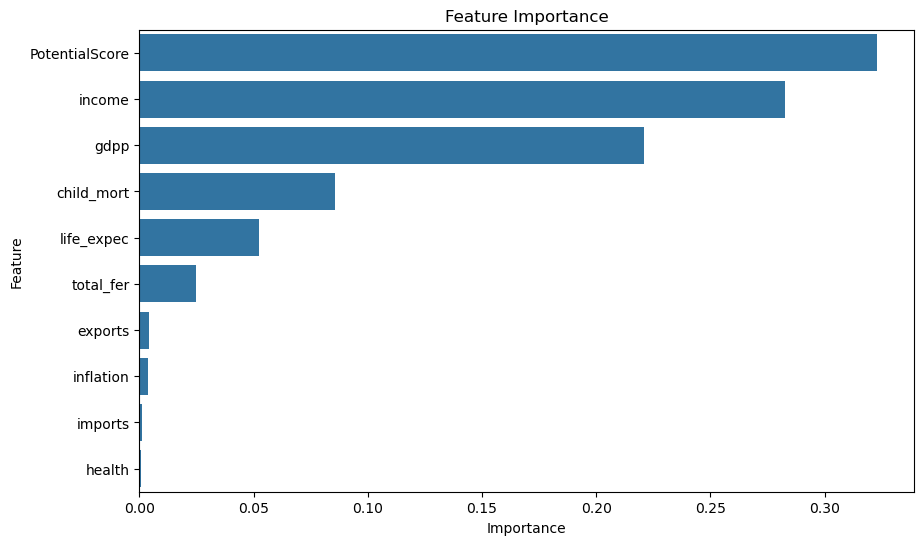

In [146]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance,

    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

Graphical representation of the same feature importance

In [147]:
print(df.columns)

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp', 'PotentialScore',
       'Target', 'Cluster', 'DBSCAN_Cluster'],
      dtype='object')


In [148]:
df["PotentialScore"] = (
      0.40 * df["income"]
    + 0.40 * df["gdpp"]
    + 0.20 * df["life_expec"]
)

median_score = df["PotentialScore"].median()

df["Target"] = np.where(
    df["PotentialScore"] > median_score,
    1,
    0
)

Implementing the above code again, beacause we require target but initially while the classification, we droped the column Target.

**0- High Potential Countries**

**Characteristics:**

High Income  ,
High GDP per capita (gdpp) ,
Higher Life Expectancy,
Better Economic Development,
Better Purchasing Power

**1- Low Potential Countries**

**Characterstics:**

Low Income
Low GDP per capita (gdpp)
Lower Life Expentancy
Lower Economic Development
Lower Purchasing Power

In [177]:
df[["country","PotentialScore","Target"]].head()

,country,PotentialScore,Target
0,Afghanistan,876.44,0
1,Albania,5623.26,0
2,Algeria,6959.30,1
3,Angola,3784.02,0
4,Antigua and Barbuda,12535.36,1


In [150]:
high_potential = df[df["Target"] == 1]

high_potential[
    ["country","income","gdpp","life_expec"]
].head(20)

,country,income,gdpp,life_expec
2,Algeria,12900,4460,76.5
4,Antigua and Barbuda,19100,12200,76.8
5,Argentina,18700,10300,75.8
7,Australia,41400,51900,82.0
8,Austria,43200,46900,80.5
9,Azerbaijan,16000,5840,69.1
10,Bahamas,22900,28000,73.8
11,Bahrain,41100,20700,76.0
13,Barbados,15300,16000,76.7
14,Belarus,16200,6030,70.4


All the countries mentioned above are actually having Target=1

In [151]:
print("Total Countries:",len(df))

print(
    "High Potential Countries:",
    len(df[df["Target"]==1])
)

print(
    "Low Potential Countries:",
    len(df[df["Target"]==0])
)

Total Countries: 167
High Potential Countries: 83
Low Potential Countries: 84


In [152]:
low_potential = df[df["Target"] == 0]

low_potential[
    ["country","income","gdpp","life_expec"]
].head(84)

,country,income,gdpp,life_expec
0,Afghanistan,1610,553,56.2
1,Albania,9930,4090,76.3
3,Angola,5900,3530,60.1
6,Armenia,6700,3220,73.3
12,Bangladesh,2440,758,70.4
...,...,...,...,...
161,Uzbekistan,4240,1380,68.8
162,Vanuatu,2950,2970,63.0
164,Vietnam,4490,1310,73.1
165,Yemen,4480,1310,67.5


Testing

Testing-1
With Country names

In [154]:
country_names = df["country"]
country_test = country_names.loc[X_test.index]

results = pd.DataFrame({
    "Country": country_test,
    "Actual": y_test,
    "Predicted": pred_rf
})

results.head(20)


,Country,Actual,Predicted
47,Egypt,0,0
11,Bahrain,1,1
105,Morocco,0,0
71,Iran,1,1
89,Libya,1,1
156,Ukraine,0,0
3,Angola,0,0
137,South Africa,1,1
122,Portugal,1,1
2,Algeria,1,1


Testing 2:
By introducing a new country and classifying that it will be 0 or 1

In [174]:
new_country = pd.DataFrame({
    "child_mort":[20],
    "exports":[45],
    "health":[7],
    "imports":[40],
    "income":[18000],
    "inflation":[4],
    "life_expec":[75],
    "total_fer":[2.1],
    "gdpp":[15000],
    "PotentialScore":[13200]
})

prediction = rf.predict(new_country)

print(prediction)

[1]
